# LSTM-VAE Optuna — Busqueda de Hiperparametros v1
## Dataset: SWaT A12 (Marzo 2026)

### Contexto

- **v1** (beta=1.0): ROC-AUC=0.52 — posterior collapse.
- **v2** (beta=0.1, hidden=128, latent=64, alpha=0.9, lr=5e-4): ROC-AUC=0.76 — arquitectura validada.
- **Este notebook**: busqueda sistematica con Optuna para maximizar ROC-AUC.

### Espacio de busqueda

| Parametro | Rango | Tipo |
|---|---|---|
| `beta` | [0.01, 0.5] | log-uniform |
| `hidden_size` | {64, 96, 128, 192} | categorical |
| `num_layers` | {1, 2} | categorical |
| `latent_dim` | {32, 64, 96} | categorical |
| `disc_hidden` | {32, 64} | categorical |
| `dropout` | [0.10, 0.50] | uniform |
| `alpha` | [0.80, 0.98] | uniform |
| `lr` | [1e-4, 8e-4] | log-uniform |
| `batch_size` | {64, 128} | categorical |

### Estrategia

- **Sampler**: TPESampler con startup_trials=10 (explora al azar los primeros 10 y luego usa TPE).
- **Pruner**: MedianPruner — corta trials que van mal antes de terminar.
- **Trial budget**: cada trial entrena maximo 60 epochs con patience=12 (rapido).
  El mejor trial se reentrena hasta 150 epochs para la evaluacion final.
- **Objetivo**: ROC-AUC sobre el CSV completo etiquetado (igual que Conv1D Optuna).

### Flujo

```
02c_optuna (este notebook):
  1. Prepara datos una sola vez (fuera del loop de trials)
  2. Ejecuta N_TRIALS trials de Optuna
  3. Reentrena el mejor trial con 150 epochs
  4. Guarda optuna_best_config.json -> usado por 02b_lstm_vae_a12_v3.ipynb
```


## 0. Imports

In [1]:
import json, joblib, random, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import warnings; warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # silenciar logs internos


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
COL_CFG    = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_optuna_v3' / 'optuna_best_config.json'
SAVE_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('CSV:', RAW_CSV.exists())
print('Col cfg:', COL_CFG.exists())
print('Save dir:', SAVE_DIR)


CSV: True
Col cfg: True
Save dir: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_optuna_v1


## 2. Parametros fijos del pipeline

Estos no se buscan con Optuna — son los mismos que v2 para garantizar
comparabilidad directa.

In [4]:
with open(COL_CFG) as f:
    col_cfg = json.load(f)

continuous_cols = col_cfg['continuous_cols']
discrete_cols   = col_cfg['discrete_cols']
feature_cols    = col_cfg['feature_cols']
STRIDE_FIXED    = int(col_cfg['best_params']['stride'])  # stride fijo del Conv1D Optuna

WINDOW_SIZE   = 60      # Fijo — igual que Conv1D y v2
CLIP_VAL      = 5.0     # Fijo
WARMUP        = 120     # Fijo
DISC_HIDDEN   = 64      # Fijo — la rama discreta es simple, no vale la pena buscarla

# Optuna trial budget
N_TRIALS          = 50
MAX_TRIAL_EPOCHS  = 60   # Epochs por trial (rapido)
TRIAL_PATIENCE    = 12   # Early stop dentro del trial

# Reentrenamiento del mejor trial
MAX_RETRAIN_EPOCHS = 150
RETRAIN_PATIENCE   = 20

print(f'Columnas: {len(continuous_cols)} continuas | {len(discrete_cols)} discretas')
print(f'window={WINDOW_SIZE} | stride={STRIDE_FIXED} | clip={CLIP_VAL}')
print(f'N_TRIALS={N_TRIALS} | trial_epochs={MAX_TRIAL_EPOCHS} | retrain_epochs={MAX_RETRAIN_EPOCHS}')


Columnas: 31 continuas | 31 discretas
window=60 | stride=10 | clip=5.0
N_TRIALS=50 | trial_epochs=60 | retrain_epochs=150


## 3. Carga y preprocesamiento

Identico a v2 — se ejecuta una sola vez, fuera del loop de trials.

In [5]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

df_all = df_raw[['t_stamp', 'attack_label'] + feature_cols].copy()
for col in feature_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input', np.nan), errors='coerce')

df_work = df_all[df_all['attack_label'] == 0][['t_stamp'] + feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min() + pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

n        = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

print(f'Normal: {len(df_work):,} | Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Normal: 25,620 | Train: 15,372 | Val: 5,124 | Test: 5,124


In [6]:
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)
disc_max = df_train[discrete_cols].max().replace(0, 1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = np.clip(
        scaler_cont.transform(df[continuous_cols].values), -CLIP_VAL, CLIP_VAL
    )
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

rng = df_train_sc[continuous_cols].values.min(), df_train_sc[continuous_cols].values.max()
print(f'Train cont tras clip: [{rng[0]:.2f}, {rng[1]:.2f}]')


Train cont tras clip: [-5.00, 5.00]


## 4. Ventanas

Se construyen una sola vez. Todos los trials usan los mismos arrays —
no se reconstruyen en cada trial para no perder tiempo.

In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, discrete_cols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows(df_sc, ws, stride):
    raw_c = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    raw_d = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    if len(raw_c) == 0: return None, None
    return raw_c, summarize_discrete_windows(raw_d, discrete_cols).values.astype(np.float32)

X_tr_c, X_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE_FIXED)
X_va_c, X_va_d = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE_FIXED)

# Ventanas etiquetadas para evaluacion (todo el CSV)
df_eval = df_all[['t_stamp', 'attack_label'] + feature_cols].copy()
df_eval[feature_cols]    = df_eval[feature_cols].fillna(modes_train)
df_eval[continuous_cols] = np.clip(scaler_cont.transform(df_eval[continuous_cols].values), -CLIP_VAL, CLIP_VAL)
df_eval[discrete_cols]   = (df_eval[discrete_cols] / disc_max).clip(0, 1)

cont_arr = df_eval[continuous_cols].values.astype(np.float32)
disc_arr = df_eval[discrete_cols].values.astype(np.float32)
labs_arr = df_eval['attack_label'].values

wins_c, wins_d, wins_y = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE_FIXED):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    wins_y.append(int(np.any(labs_arr[s:s+WINDOW_SIZE] == 1)))

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
y_eval   = np.array(wins_y, dtype=int)

CONT_SIZE = X_tr_c.shape[2]
DISC_DIM  = X_tr_d.shape[1]

print(f'Train: {X_tr_c.shape} | Val: {X_va_c.shape}')
print(f'Eval: {X_eval_c.shape} | Normal: {(y_eval==0).sum()} | Ataque: {(y_eval==1).sum()} ({100*y_eval.mean():.1f}%)')


Train: (1532, 60, 31) | Val: (507, 60, 31)
Eval: (2881, 60, 31) | Normal: 2519 | Ataque: 362 (12.6%)


## 5. Arquitectura (identica a v2)

In [8]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_last = self.drop(h[-1])
        return self.fc_mu(h_last), self.fc_logvar(h_last)


class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len     = seq_len
        self.num_layers  = num_layers
        self.fc_h0       = nn.Linear(latent_dim, hidden_size)
        self.lstm        = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                    dropout=dropout if num_layers > 1 else 0.0)
        self.drop        = nn.Dropout(dropout)
        self.fc_out      = nn.Linear(hidden_size, output_size)

    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        z_rep = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.lstm(z_rep, (h0, c0))
        return self.fc_out(self.drop(out))


class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64,
                 disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU()
        )
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim)
        )

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu

    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z          = self.reparameterize(mu, logvar)
        xc_hat     = self.decoder_cont(z)
        h_d        = self.encoder_disc(xd)
        xd_hat     = self.decoder_disc(h_d)
        return xc_hat, xd_hat, mu, logvar


def elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta):
    mse_c = nn.functional.mse_loss(xc_hat, xc)
    mse_d = nn.functional.mse_loss(xd_hat, xd)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return alpha * (mse_c + beta * kl) + (1 - alpha) * mse_d, mse_c, mse_d, kl


def recon_errors(model, Xc, Xd, alpha, bs=256):
    loader = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                      torch.tensor(Xd, dtype=torch.float32)),
                        batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat - xc)**2, dim=(1, 2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat - xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return ec, ed, alpha * ec + (1 - alpha) * ed


print('Clases definidas: LSTMEncoder, LSTMDecoder, HybridLSTMVAE, elbo_loss, recon_errors')


Clases definidas: LSTMEncoder, LSTMDecoder, HybridLSTMVAE, elbo_loss, recon_errors


## 6. Funcion objetivo Optuna

Cada trial:
1. Sugiere hiperparametros del espacio de busqueda.
2. Entrena el modelo maximo `MAX_TRIAL_EPOCHS` epochs.
3. Reporta el AUC intermedio cada 5 epochs (permite pruning).
4. Devuelve ROC-AUC final sobre el CSV completo etiquetado.
5. Limpia la GPU antes de salir.


In [9]:
def build_model(params):
    return HybridLSTMVAE(
        cont_size   = CONT_SIZE,
        seq_len     = WINDOW_SIZE,
        disc_dim    = DISC_DIM,
        hidden_size = params['hidden_size'],
        num_layers  = params['num_layers'],
        latent_dim  = params['latent_dim'],
        disc_hidden = DISC_HIDDEN,
        dropout     = params['dropout'],
    ).to(device)


def train_eval(params, max_epochs, patience, trial=None):
    """Entrena y evalua un modelo con los params dados.
    Si trial != None, reporta valores intermedios para pruning.
    Retorna (auc, model_state_dict).
    """
    alpha = params['alpha']
    beta  = params['beta']

    model = build_model(params)
    optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6
    )

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr_c, dtype=torch.float32),
                      torch.tensor(X_tr_d, dtype=torch.float32)),
        batch_size=params['batch_size'], shuffle=True, drop_last=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_va_c, dtype=torch.float32),
                      torch.tensor(X_va_d, dtype=torch.float32)),
        batch_size=params['batch_size'], shuffle=False
    )

    best_val, best_wts, no_improve = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xc, xd in train_loader:
            xc, xd = xc.to(device), xd.to(device)
            optimizer.zero_grad()
            xc_hat, xd_hat, mu, logvar = model(xc, xd)
            loss = elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta)[0]
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xc, xd in val_loader:
                xc, xd = xc.to(device), xd.to(device)
                xc_hat, xd_hat, mu, logvar = model(xc, xd)
                vl += elbo_loss(xc, xc_hat, xd, xd_hat, mu, logvar, alpha, beta)[0].item()
        vl /= len(val_loader)
        scheduler.step(vl)

        if vl < best_val - 1e-6:
            best_val = vl
            best_wts = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        # Pruning: reportar AUC intermedio cada 5 epochs
        if trial is not None and epoch % 5 == 0:
            model.load_state_dict(best_wts)
            _, _, scores_inter = recon_errors(model, X_eval_c, X_eval_d, alpha)
            auc_inter = roc_auc_score(y_eval, scores_inter)
            trial.report(auc_inter, epoch)
            if trial.should_prune():
                del model; torch.cuda.empty_cache(); gc.collect()
                raise optuna.exceptions.TrialPruned()
            model.train()

        if no_improve >= patience:
            break

    model.load_state_dict(best_wts)
    model.eval()
    _, _, scores = recon_errors(model, X_eval_c, X_eval_d, alpha)
    auc = roc_auc_score(y_eval, scores)

    state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    del model; torch.cuda.empty_cache(); gc.collect()
    return auc, state


def objective(trial):
    params = {
        'hidden_size' : trial.suggest_categorical('hidden_size', [64, 96, 128, 192]),
        'num_layers'  : trial.suggest_categorical('num_layers',  [1, 2]),
        'latent_dim'  : trial.suggest_categorical('latent_dim',  [32, 64, 96]),
        'dropout'     : trial.suggest_float('dropout', 0.10, 0.50),
        'beta'        : trial.suggest_float('beta',    0.01, 0.50, log=True),
        'alpha'       : trial.suggest_float('alpha',   0.80, 0.98),
        'lr'          : trial.suggest_float('lr',      1e-4, 8e-4, log=True),
        'batch_size'  : trial.suggest_categorical('batch_size', [64, 128]),
    }
    auc, _ = train_eval(params, MAX_TRIAL_EPOCHS, TRIAL_PATIENCE, trial=trial)
    return auc


print('Funcion objetivo definida.')


Funcion objetivo definida.


## 7. Ejecutar estudio Optuna

El estudio se guarda en un archivo SQLite local. Si la celda se interrumpe
y se vuelve a ejecutar, Optuna retoma desde donde quedo.

In [10]:
DB_PATH = SAVE_DIR / 'optuna_study.db'

study = optuna.create_study(
    study_name   = 'lstm_vae_a12_v1',
    direction    = 'maximize',
    sampler      = TPESampler(seed=SEED, n_startup_trials=10),
    pruner       = MedianPruner(n_startup_trials=10, n_warmup_steps=10, interval_steps=5),
    storage      = f'sqlite:///{DB_PATH}',
    load_if_exists = True,   # Reanuda si ya existe
)

trials_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
trials_left = max(0, N_TRIALS - trials_done)
print(f'Trials completos: {trials_done} | Pendientes: {trials_left}')

if trials_left > 0:
    study.optimize(
        objective,
        n_trials  = trials_left,
        show_progress_bar = True,
    )

best = study.best_trial
print(f'\nMejor trial #{best.number} — ROC-AUC: {best.value:.4f}')
for k, v in best.params.items():
    print(f'  {k:<15}: {v}')


Trials completos: 0 | Pendientes: 50


Best trial: 2. Best value: 0.794617: 100%|██████████| 50/50 [05:37<00:00,  6.75s/it]


Mejor trial #2 — ROC-AUC: 0.7946
  hidden_size    : 192
  num_layers     : 1
  latent_dim     : 96
  dropout        : 0.27606099749584057
  beta           : 0.016119044727609194
  alpha          : 0.8891318438200286
  lr             : 0.00010741277311947197
  batch_size     : 64


## 8. Reentrenamiento del mejor trial

Se reentrena con los mejores hiperparametros usando `MAX_RETRAIN_EPOCHS=150`
y `PATIENCE=20` para obtener el modelo final de calidad.

In [11]:
best_params = dict(best.params)
print('Reentrenando con:')
for k, v in best_params.items(): print(f'  {k:<15}: {v}')
print()

best_auc, best_state = train_eval(
    best_params,
    max_epochs = MAX_RETRAIN_EPOCHS,
    patience   = RETRAIN_PATIENCE,
    trial      = None   # Sin pruning en el reentrenamiento
)
print(f'ROC-AUC reentrenamiento: {best_auc:.4f}')


Reentrenando con:
  hidden_size    : 192
  num_layers     : 1
  latent_dim     : 96
  dropout        : 0.27606099749584057
  beta           : 0.016119044727609194
  alpha          : 0.8891318438200286
  lr             : 0.00010741277311947197
  batch_size     : 64

ROC-AUC reentrenamiento: 0.7884


## 9. Analisis de resultados

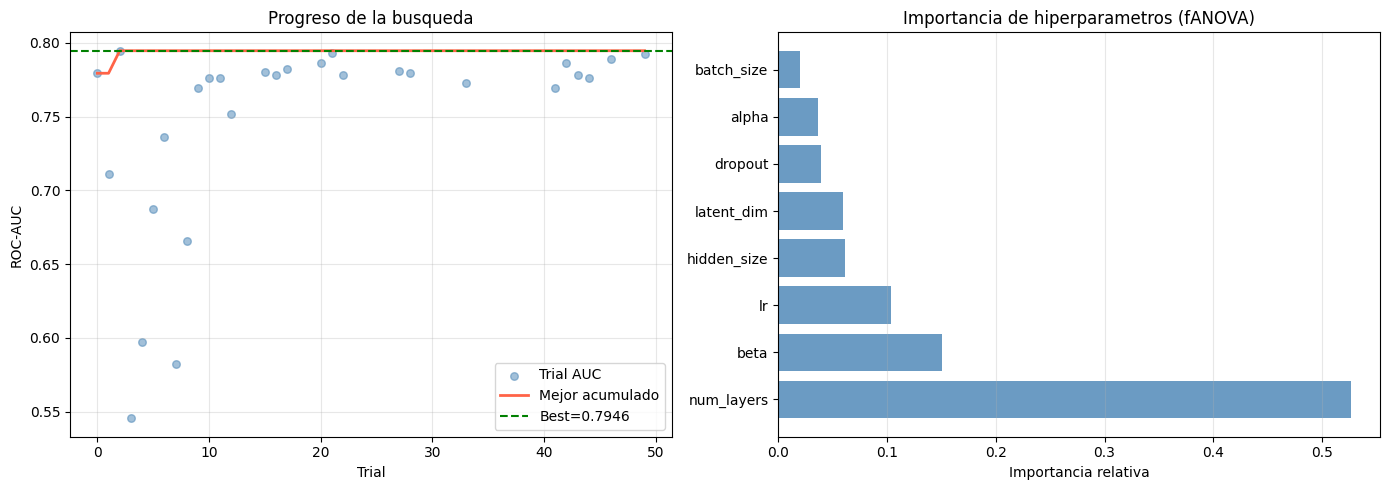

In [12]:
# Historia de trials: AUC por numero de trial
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
trial_aucs = [t.value  for t in completed]
best_so_far = np.maximum.accumulate(trial_aucs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(trial_nums, trial_aucs, alpha=0.5, s=30, color='steelblue', label='Trial AUC')
axes[0].plot(trial_nums, best_so_far, color='tomato', lw=2, label='Mejor acumulado')
axes[0].axhline(best.value, color='green', linestyle='--', lw=1.5, label=f'Best={best.value:.4f}')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Progreso de la busqueda')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Importancia de parametros
try:
    importances = optuna.importance.get_param_importances(study)
    names  = list(importances.keys())
    values = list(importances.values())
    axes[1].barh(names, values, color='steelblue', alpha=0.8)
    axes[1].set_xlabel('Importancia relativa')
    axes[1].set_title('Importancia de hiperparametros (fANOVA)')
    axes[1].grid(True, alpha=0.3, axis='x')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Importancia no disponible:\n{e}', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'optuna_progress.png'), dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# Top 10 trials
top10 = sorted(completed, key=lambda t: t.value, reverse=True)[:10]
print('Top 10 trials:')
print(f'{"#":>4}  {"AUC":>7}  {"hidden":>7}  {"layers":>7}  {"latent":>7}  {"beta":>7}  {"alpha":>7}  {"dropout":>8}  {"lr":>9}  {"bs":>4}')
for t in top10:
    p = t.params
    print(f'{t.number:>4}  {t.value:>7.4f}  {p["hidden_size"]:>7}  {p["num_layers"]:>7}  '
          f'{p["latent_dim"]:>7}  {p["beta"]:>7.3f}  {p["alpha"]:>7.3f}  '
          f'{p["dropout"]:>8.3f}  {p["lr"]:>9.2e}  {p["batch_size"]:>4}')


Top 10 trials:
   #      AUC   hidden   layers   latent     beta    alpha   dropout         lr    bs
   2   0.7946      192        1       96    0.016    0.889     0.276   1.07e-04    64
  21   0.7929      192        1       96    0.041    0.960     0.315   2.06e-04    64
  49   0.7922      192        1       96    0.019    0.979     0.330   2.85e-04    64
  46   0.7891      192        1       96    0.017    0.957     0.331   3.59e-04    64
  20   0.7861      192        1       96    0.054    0.954     0.314   1.95e-04    64
  42   0.7861      192        1       96    0.010    0.925     0.276   3.08e-04    64
  17   0.7822      192        1       64    0.048    0.948     0.274   2.11e-04    64
  27   0.7812      192        1       96    0.043    0.918     0.290   2.55e-04    64
  15   0.7799      192        1       64    0.022    0.952     0.486   3.96e-04    64
   0   0.7793       96        1       64    0.011    0.975     0.383   5.65e-04    64


## 10. Guardar config del mejor trial

Guarda `optuna_best_config.json` en el mismo formato que el Conv1D Optuna,
para que `02b_lstm_vae_a12_v3.ipynb` lo cargue directamente.

In [14]:
# Guardar modelo reentrenado
torch.save(best_state, SAVE_DIR / 'best_model_state.pt')
joblib.dump(scaler_cont,        SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR / 'disc_max_dict.pkl')

best_config = {
    'study_name'       : 'lstm_vae_a12_v1',
    'best_trial'       : best.number,
    'best_auc_optuna'  : float(best.value),
    'best_auc_retrain' : float(best_auc),
    'n_trials_run'     : len(completed),
    # Columnas (mismo formato que Conv1D optuna para compatibilidad)
    'continuous_cols'  : continuous_cols,
    'discrete_cols'    : discrete_cols,
    'feature_cols'     : feature_cols,
    # Params fijos del pipeline
    'window_size'      : WINDOW_SIZE,
    'stride'           : STRIDE_FIXED,
    'clip_val'         : CLIP_VAL,
    'disc_hidden'      : DISC_HIDDEN,
    # Mejores hiperparametros encontrados
    'best_params'      : {k: (float(v) if isinstance(v, float) else v)
                          for k, v in best_params.items()},
}

with open(SAVE_DIR / 'optuna_best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)

print('Guardado en:', SAVE_DIR.resolve())
for fp in sorted(SAVE_DIR.iterdir()): print(f'  {fp.name}')
print()
print(f'Mejor AUC (trial):      {best.value:.4f}')
print(f'Mejor AUC (retrain):    {best_auc:.4f}')
print(f'-> Cargar en v3 desde: {SAVE_DIR / "optuna_best_config.json"}')


Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_optuna_v1
  best_model_state.pt
  disc_max_dict.pkl
  optuna_best_config.json
  optuna_progress.png
  optuna_study.db
  scaler_cont.pkl

Mejor AUC (trial):      0.7946
Mejor AUC (retrain):    0.7884
-> Cargar en v3 desde: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_optuna_v1\optuna_best_config.json
